<a href="https://colab.research.google.com/github/emilchafigoulline/Data-Science/blob/main/Unit8/Unit8ExercisesSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Bartian Theory

In [ ]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns
import graphviz as gv
!pip install pymc-bart
import pymc_bart as pmb
!pip install preliz

**Task1**:

Draw a decision tree--on a physical piece of paper--that predicts how many calories you burn in a day, using time you spent exercising that day (in minutes) as a predictor.

To help you understand what you're doing with this tree, seperately create an x/y plot with time exercising as x, and calories burned as y.

If this seems to easy, then add another variable or two (type of exercise?), and/or increase the depth of your tree.

You do not have to show me or turn in your tree to earn credit for this question, although I would like to see your drawing.

**Task2**:

What is a decision tree? How do they work?

A decision tree is a way to model data. The way that they do this is by taking a series of true/false splits in the data with inequalities, which allows the data to be broken into buckets that fill a specific range. The tree learns these by splitting data into similar groups.

**Task3**:

What does the "depth" of a decision tree mean?

How do I know if a tree is too deep, or not deep enough?

The depth of the decision tree means the number of splits that it sorts the data into. For example, a depth of one means one split, while a depth of four means four splits. While we can't know for sure whether a tree is the correct depth, we can see signals of overfitting or underfitting, which may indicate that the tree is either too deep or not deep enough.

**Task4:**

How are BART models similar and different from a decision tree?

BART models and decision trees share many aspects because BART (Bayesian Additive Regression Trees) are simply many decision trees averaged together to make a prediction, while decision trees use a single tree. As such, while they use the same basic structure, BART models have many more trees.

**Task5**:

Why would we use a BART model instead of a decision tree?

We should use a BART model instead of a decision tree because a BART model is more likely to prevent overfitting, obtaining the same accuracy of prediction to the data while still maintaining adaptability to the real world.

## Bartian Penguins

**Task6**:

Create a BART model that uses flipper length, bill depth, and bill length to predict body mass in penguins, and make a ppc to check its fit

Code for loading the data is below. You'll need to do everything else yourself.

Remember to use my notes as a reference, and to copy and paste from them when it makes sense to.

Oh, and try a normal likelihood.

In [5]:
#drop the incomplete rows from the data
columns = ["species", "island", "bill_length", "bill_depth", "flipper_length", "body_mass", "sex", "year"]
url="https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/penguins.csv"
penguin = pd.read_csv(url)
penguins = penguin.loc[:,columns].dropna()

In [6]:
X = penguins[["flipper_length", "bill_depth", "bill_length"]]
Y = penguins["body_mass"].to_numpy()
penguins.head()

,species,island,bill_length,bill_depth,flipper_length,body_mass,sex,year
0,Adelie,Torgersen,3.91,1.87,18.1,3.75,male,2007
1,Adelie,Torgersen,3.95,1.74,18.6,3.80,female,2007
2,Adelie,Torgersen,4.03,1.80,19.5,3.25,female,2007
4,Adelie,Torgersen,3.67,1.93,19.3,3.45,female,2007
5,Adelie,Torgersen,3.93,2.06,19.0,3.65,male,2007


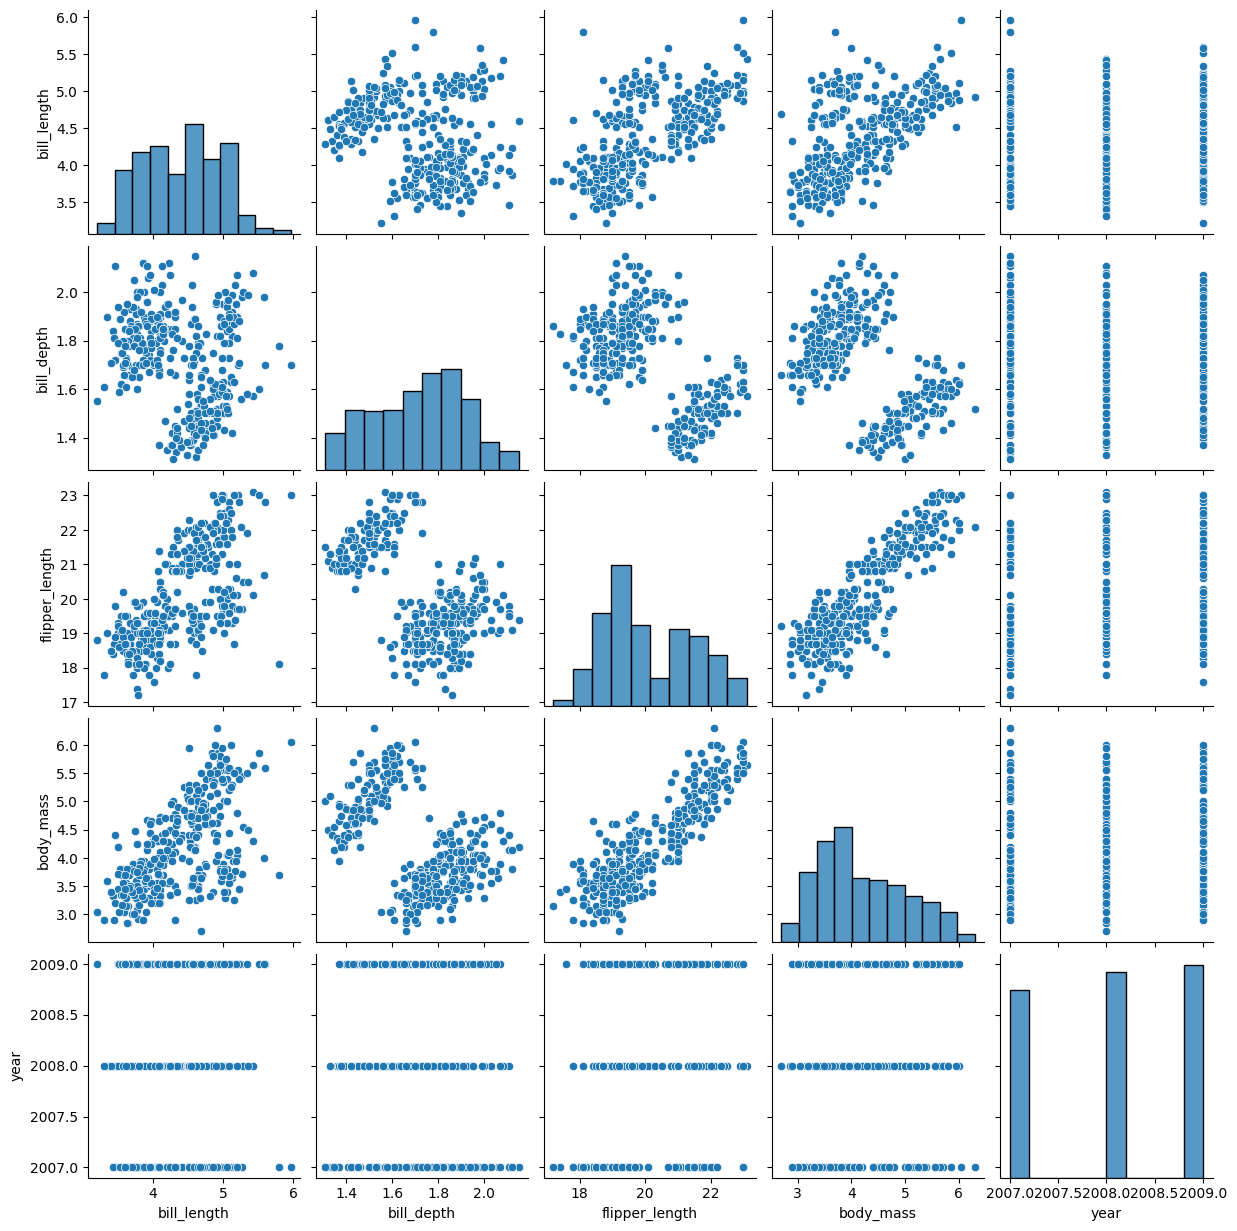

In [7]:
sns.pairplot(penguins)

In [ ]:
with pm.Model() as model_penguins:
    s = pm.HalfNormal('s', 10)
    μ_ = pmb.BART("μ_", X, np.log(Y), m=50)
    μ = pm.Deterministic("μ",pm.math.exp(μ_))
    y = pm.Normal("y", mu=μ, sigma=s,  observed=Y)
    idata_penguins = pm.sample(compute_convergence_checks=False)

In [ ]:

pm.sample_posterior_predictive(idata_penguins,model_penguins, extend_inferencedata=True)

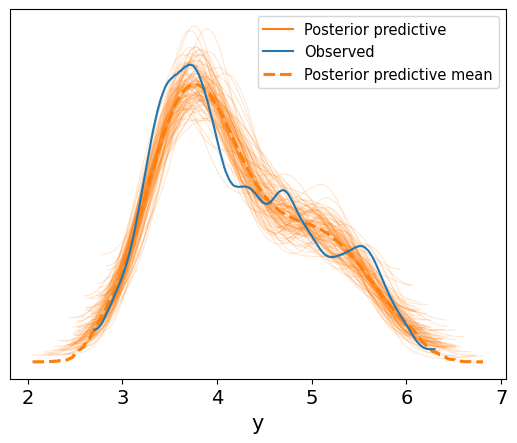

In [10]:
ax = az.plot_ppc(idata_penguins, num_pp_samples=100, colors=["C1", "C0", "C1"])

**Task7**:

Plot flipper length versus body mass,

and then plot the posterior predictve from the model over the data.
You're going to copy paste the plotting code from the notes, fyi.

<Axes: xlabel='flipper_length', ylabel='body_mass'>

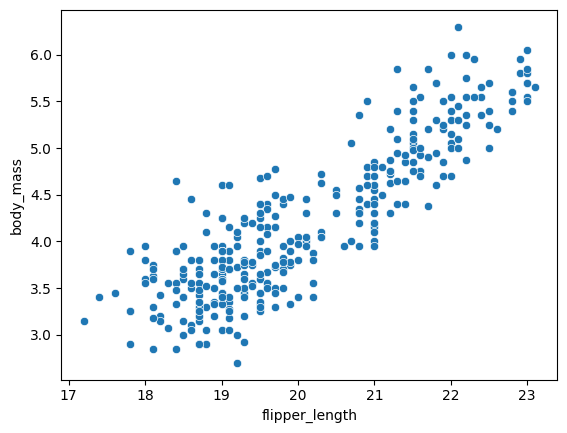

In [11]:
sns.scatterplot(data = penguins, y = 'body_mass', x = 'flipper_length')

In [12]:
posterior_mean = idata_penguins.posterior["μ"]

μ_hdi = az.hdi(ary=idata_penguins, group="posterior", var_names=["μ"], hdi_prob=0.74)

pps = az.extract(
    idata_penguins, group="posterior_predictive", var_names=["y"]
).T

/usr/local/lib/python3.12/dist-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)


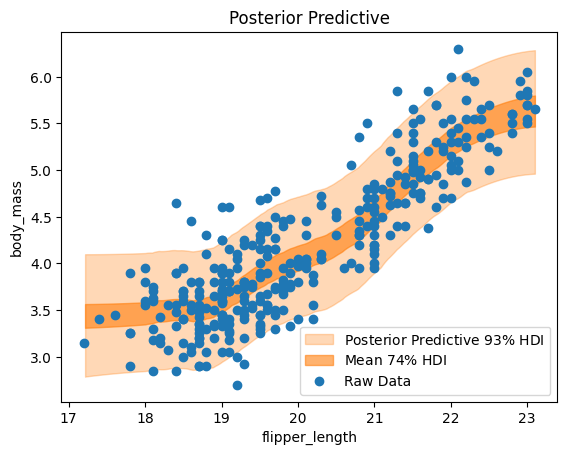

In [13]:

idx = np.argsort(X.to_numpy()[:, 0])
fig, ax = plt.subplots()

az.plot_hdi(
    x=X.to_numpy()[:, 0],
    y=pps,
    ax=ax,
    hdi_prob=0.93,
    fill_kwargs={"alpha": 0.3, "label": r"Posterior Predictive $93\%$ HDI"},
)

az.plot_hdi(
    x=X.to_numpy()[:, 0],
    y=posterior_mean,
    ax=ax,
    hdi_prob=0.74,
    fill_kwargs={"alpha": 0.6, "label": r"Mean $74\%$ HDI"},
)
ax.plot(penguins['flipper_length'], penguins["body_mass"], "o", c="C0", label="Raw Data")
ax.legend(loc="lower right")
ax.set(
    title="Posterior Predictive",
    xlabel="flipper_length",
    ylabel="body_mass",
);

**Task8**:

Interpret the plot above in context. Do you think it captures the true association between flipper length and body mass in penguins? Why or why not? Make sure to reference specific things you see in the plot.

For the life of me I couldn't get this to work. However, from what we can see in the plot, the shape and the general slope of the plot are the same as that of the model, indicating that it would fit well if I could get the model to work as intended.

-After fixing the order of variables: The plot fits well into the penguin data, capturing the strong relatinoship between flipper length and body mass. We can see that the bottom of the model levels out, which while typical to BART models is also capturing the data well. In addition, the rest of the model fits the data quite well.

**Task9**:

Create partial depnedence plots (pdps), individual conditional expectation (ice) plots, and a variable importance plot for the BARTpenguin model.

array([<Axes: xlabel='flipper_length'>, <Axes: xlabel='bill_depth'>,
       <Axes: xlabel='bill_length'>], dtype=object)

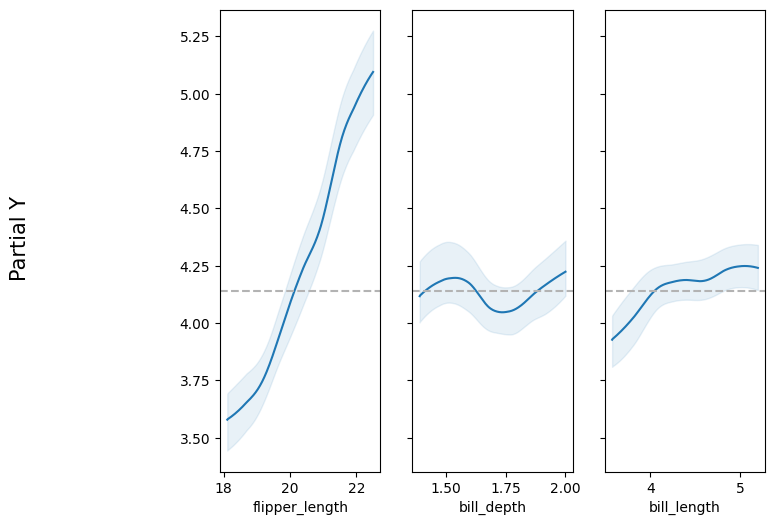

In [14]:
pmb.plot_pdp(μ_, X, Y, grid=(1, 5), func=np.exp, figsize = (12,6))

array([<Axes: xlabel='flipper_length'>, <Axes: xlabel='bill_depth'>,
       <Axes: xlabel='bill_length'>], dtype=object)

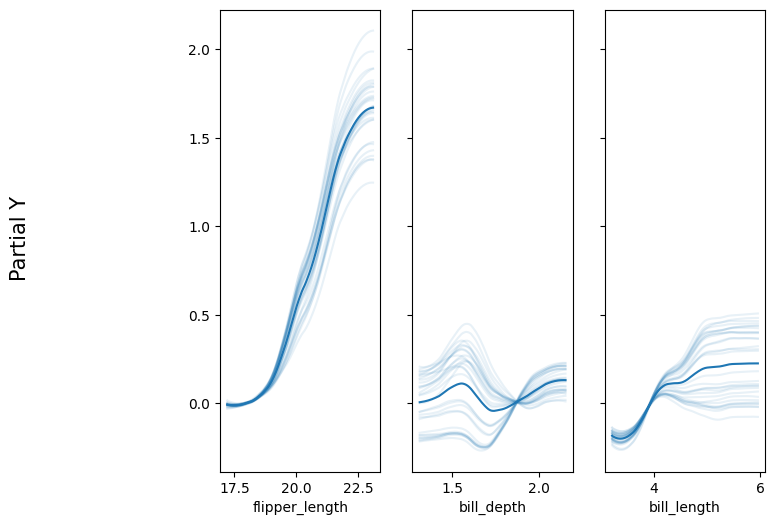

In [15]:
pmb.plot_ice( μ_, X, Y, grid=(1, 5), func=np.exp, figsize = (12,6))

<Axes: ylabel='R²'>

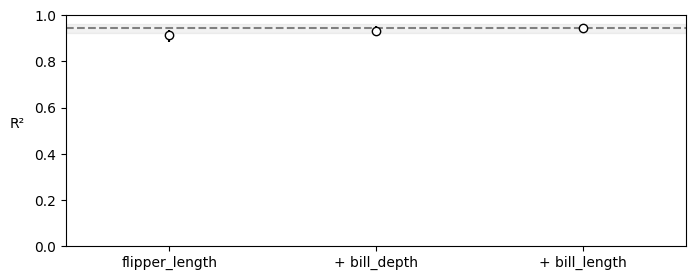

In [16]:

vi_pengs = pmb.compute_variable_importance(idata_penguins, μ_, X)
pmb.plot_variable_importance(vi_pengs)


**Task10**:

Using the above plots, make an argument about which variable(s) is/are most important in predicting body mass in penguins.

What is the relationship for each variable to body mass, when you take the other variables into account?

Is that relationship complicated by interactions between variables? How do you know?

Make sure to reference specific things you see in each plot, to justify your decisions and comments.

flipper length is by far the best predictor for body mass in penguins, which is seen in both the PDP and ICE plots. In the variable independence plot, we see that flipper length alone accounts for over 95% of the change in body mass, while bill depth and length have a negligible effect. In addition, we can see in the PDP plot that flipper length and body mass have an almost linear relationship, while the other two factors don't have a particularly strong correlation. All this points to flipper length being the best predictor of penguin body mass.